In [10]:
import wandb
import pandas as pd
import os
import json

import seaborn as sns
import matplotlib.pyplot as plt

wandb.login()
api = wandb.Api()

In [ ]:
run_names = [
    "18M_2025.08.31_09.35",
    "32M_2025.08.31_12.06",
    # "73M_2025.08.24_09.01",
    "73M_2025.08.31_05.11",
    "130M_2025.08.24_09.01",
    "j2tkor55",
    "xjdm3gvb",
    "73M_2025.08.30_08.19",
    "130M_2025.08.30_08.19",
]

In [15]:
dfs = []

for run_name in run_names:
    
    parquet_path = f"plots/datapoints/{run_name}.parquet"
    config_path= f"plots/datapoints/{run_name}.json"


    if not os.path.exists(parquet_path):
        my_run = api.run(f"samdauncey-eth-z-rich/training_random_base_model/runs/{run_name}")

        history = my_run.scan_history()
        df = pd.DataFrame(history)
        df.to_parquet(parquet_path)

        config = my_run.config
        with open(config_path, "w") as f:
            json.dump(my_run, f, indent=4)

    else:
        df = pd.read_parquet(parquet_path)
        with open(config_path, "r") as f:
            config = json.load(f)

    df['run_name'] = run_name
    df['model_size'] = config['model_size']
    df['GaterClass'] = config['GaterClass']
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)
df.head()


,flops,batch_wallclock_time,_step,ar_loss,late_ar_loss,val_ar_loss,val_total_loss,pre_clip_grad_norm,all_bytes_elapsed,val_early_ar_loss,...,_timestamp,val_mean_selected_action_ce,val_late_ar_loss,early_ar_loss,flops_elapsed,val_true_downsample_rate,non_padding_bytes,run_name,model_size,GaterClass
0,2.374978e+12,0.749340,0,8.573084,9.055325,8.521752,8.642275,13.3125,32768.0,6.64521,...,1.756626e+09,0.625732,8.990888,6.644122,2.374978e+12,0.523071,32768,18M_2025.08.31_09.35,18M,LinearGater
1,2.333503e+12,0.339947,1,8.600568,9.084674,NaN,NaN,14.3125,65536.0,NaN,...,1.756626e+09,NaN,NaN,6.664142,4.708480e+12,NaN,32768,18M_2025.08.31_09.35,18M,LinearGater
2,2.409654e+12,0.364226,2,8.437526,8.888884,NaN,NaN,13.4375,98304.0,NaN,...,1.756626e+09,NaN,NaN,6.632093,7.118134e+12,NaN,32768,18M_2025.08.31_09.35,18M,LinearGater
3,2.461328e+12,0.530008,3,8.554431,9.039497,NaN,NaN,14.5625,131072.0,NaN,...,1.756626e+09,NaN,NaN,6.614164,9.579462e+12,NaN,32768,18M_2025.08.31_09.35,18M,LinearGater
4,1.051174e+12,0.237900,4,11.854085,13.427601,NaN,NaN,35.2500,163840.0,NaN,...,1.756626e+09,NaN,NaN,5.560023,1.063064e+13,NaN,32768,18M_2025.08.31_09.35,18M,LinearGater


In [16]:
val_steps = df["val_true_downsample_rate"].notna()
df_val = df[
    val_steps
]

df_val.head()

,flops,batch_wallclock_time,_step,ar_loss,late_ar_loss,val_ar_loss,val_total_loss,pre_clip_grad_norm,all_bytes_elapsed,val_early_ar_loss,...,_timestamp,val_mean_selected_action_ce,val_late_ar_loss,early_ar_loss,flops_elapsed,val_true_downsample_rate,non_padding_bytes,run_name,model_size,GaterClass
0,2.374978e+12,0.749340,0,8.573084,9.055325,8.521752,8.642275,13.312500,32768.0,6.645210,...,1.756626e+09,0.625732,8.990888,6.644122,2.374978e+12,0.523071,32768,18M_2025.08.31_09.35,18M,LinearGater
400,1.651543e+12,0.516900,400,2.709438,2.772559,2.748716,2.740452,3.421875,13139968.0,2.509507,...,1.756626e+09,0.115997,2.808519,2.456954,6.305649e+14,0.270813,32768,18M_2025.08.31_09.35,18M,LinearGater
800,1.635905e+12,0.255147,800,2.268645,2.259535,2.244359,2.241819,0.429688,26247168.0,2.280220,...,1.756626e+09,0.033417,2.235394,2.305081,1.292540e+15,0.263428,32768,18M_2025.08.31_09.35,18M,LinearGater
1200,1.671261e+12,0.302657,1200,1.747365,1.708599,1.817326,1.816636,0.239258,39354368.0,1.949189,...,1.756626e+09,0.010626,1.784360,1.902426,1.959602e+15,0.273743,32768,18M_2025.08.31_09.35,18M,LinearGater
1600,1.690979e+12,0.345283,1600,1.607265,1.560128,1.641461,1.641726,0.154297,52461568.0,1.827665,...,1.756626e+09,0.004313,1.594910,1.795812,2.627586e+15,0.272583,32768,18M_2025.08.31_09.35,18M,LinearGater


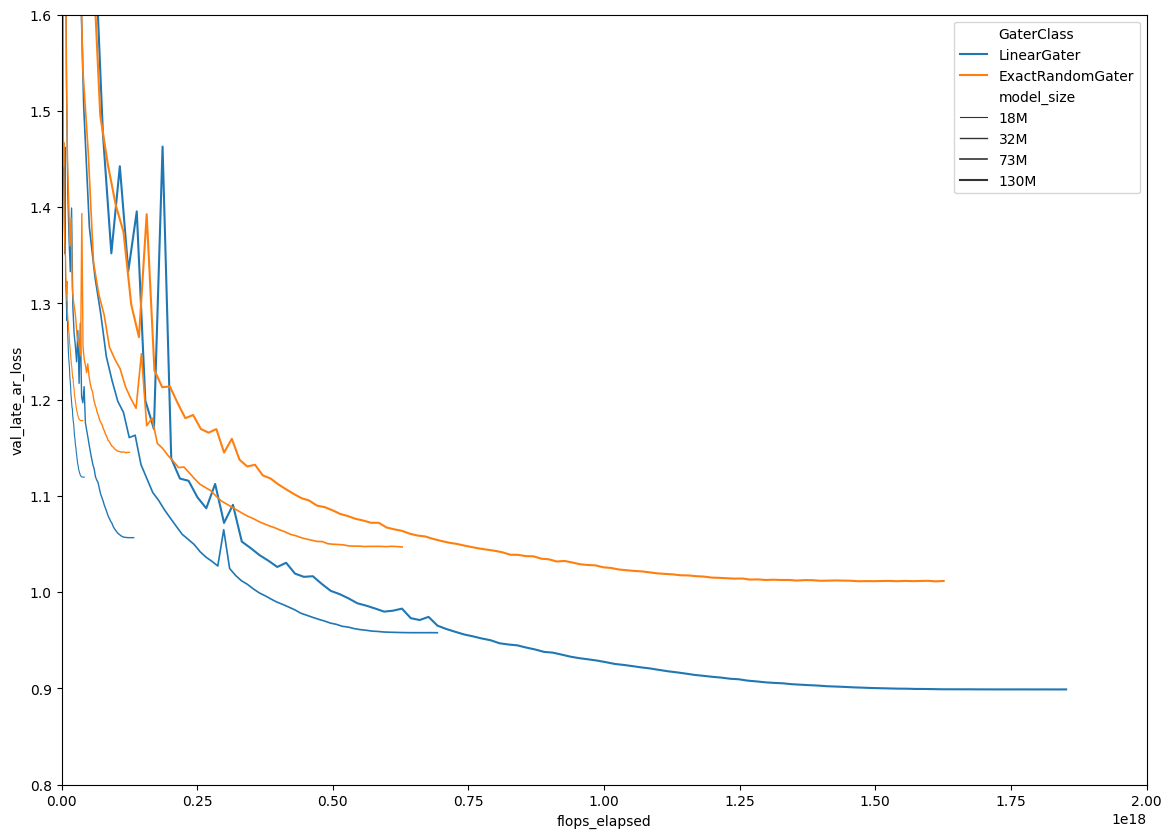

In [25]:
plt.figure(figsize=(14, 10))

sizes = {
    "18M": 0.8,
    "32M": 1.,
    "73M": 1.2,
    "130M": 1.5
}

sns.lineplot(
    data=df_val,
    x="flops_elapsed",
    y="val_late_ar_loss",
    hue="GaterClass",
    size="model_size",
    sizes=sizes
)

plt.ylim(0.8, 1.6)
plt.xlim(0, 2e18)

plt.show()